In [21]:
pip install pandas scikit-learn nltk transformers streamlit matplotlib seaborn xgboost

In [22]:
!pip install kaggle -q
import os
from google.colab import userdata
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_TOKEN')

# WELFake dataset
!kaggle datasets download -d saurabhshahane/fake-news-classification -q
!unzip -q fake-news-classification.zip

# FakeNewsNet dataset
!kaggle datasets download -d algord/fake-news -q
!unzip -q fake-news.zip

Dataset URL: https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification
License(s): Attribution 4.0 International (CC BY 4.0)
replace WELFake_Dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
Dataset URL: https://www.kaggle.com/datasets/algord/fake-news
License(s): CC0-1.0
replace FakeNewsNet.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


In [23]:
import pandas as pd

welfake = pd.read_csv('WELFake_Dataset.csv')
fnn     = pd.read_csv('FakeNewsNet.csv')

print("=== WELFake ===")
print(welfake.shape)
print(welfake.columns.tolist())
print(welfake['label'].value_counts())
print(welfake.head(2))

print("\n=== FakeNewsNet ===")
print(fnn.shape)
print(fnn.columns.tolist())
# FakeNewsNet 'real' column renamed to 'label' for easier manipulation
fnn = fnn[['title', 'real']].copy()
fnn.rename(columns={'real': 'label'}, inplace=True)
fnn['source'] = 'fakenewsnet'
print(fnn.columns.tolist())
# Verify what values are actually in it
print(fnn['label'].value_counts())
print(fnn['label'].dtype)
print(fnn.head(2))

=== WELFake ===
(72134, 4)
['Unnamed: 0', 'title', 'text', 'label']
label
1    37106
0    35028
Name: count, dtype: int64
   Unnamed: 0                                              title  \
0           0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1           1                                                NaN   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  

=== FakeNewsNet ===
(23196, 5)
['title', 'news_url', 'source_domain', 'tweet_num', 'real']
['title', 'label', 'source']
label
1    17441
0     5755
Name: count, dtype: int64
int64
                                               title  label       source
0  Kandi Burruss Explodes Over Rape Accusation on...      1  fakenewsnet
1  People's Choice Awards 2018: The best red carp...      1  fakenewsnet


In [24]:
welfake_clean = welfake[['title', 'label']].copy()
welfake_clean['label'] = welfake_clean['label'].astype(int)  # 0=fake, 1=real
welfake_clean['source'] = 'welfake'

fnn_clean = fnn[['title', 'label']].copy()
fnn_clean['label'] = fnn_clean['label'].astype(int)
fnn_clean['source'] = 'fakenewsnet'

print("WELFake label dist:\n", welfake_clean['label'].value_counts())
print("FakeNewsNet label dist:\n", fnn_clean['label'].value_counts())

WELFake label dist:
 label
1    37106
0    35028
Name: count, dtype: int64
FakeNewsNet label dist:
 label
1    17441
0     5755
Name: count, dtype: int64


In [25]:
# Combine
df = pd.concat([welfake_clean, fnn_clean], ignore_index=True)
print(f"Total rows before cleaning: {len(df)}")

# Drop rows with missing titles
df.dropna(subset=['title'], inplace=True)

# Drop rows with missing labels
df.dropna(subset=['label'], inplace=True)
df['label'] = df['label'].astype(int)

# Remove duplicate titles (same headline from different sources)
df.drop_duplicates(subset=['title'], keep='first', inplace=True)

# Clean whitespace
df['title'] = df['title'].str.strip()

# Remove very short titles (likely corrupt rows)
df = df[df['title'].str.len() > 10]

print(f"Total rows after cleaning: {len(df)}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
print(f"\nSource breakdown:\n{df['source'].value_counts()}")

Total rows before cleaning: 95330
Total rows after cleaning: 83997

Label distribution:
label
1    44350
0    39647
Name: count, dtype: int64

Source breakdown:
source
welfake        62322
fakenewsnet    21675
Name: count, dtype: int64


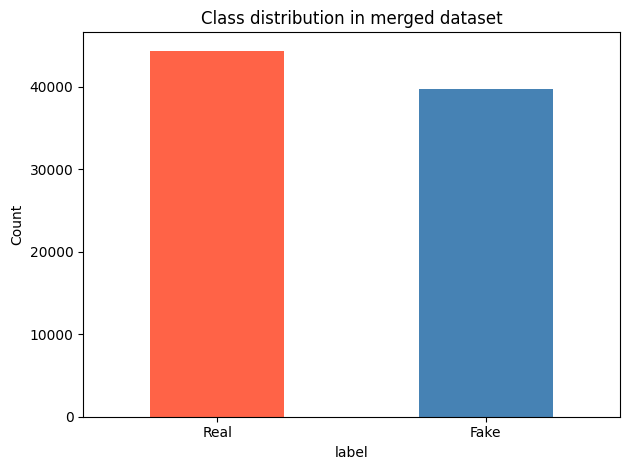

In [26]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', color=['tomato', 'steelblue'])
plt.xticks([0, 1], ['Real', 'Fake'], rotation=0)
plt.title('Class distribution in merged dataset')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [27]:
df.to_csv('merged_fakenews.csv', index=False)
print("Saved! Shape:", df.shape)

Saved! Shape: (83997, 3)


In [28]:
df.head()

,title,label,source
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1,welfake
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1,welfake
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0,welfake
4,SATAN 2: Russia unvelis an image of its terrif...,1,welfake
5,About Time! Christian Group Sues Amazon and SP...,1,welfake


In [29]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('english')) - {'not', 'no', 'never', 'against'}  # preserve negations
lemmatizer = WordNetLemmatizer()

def extract_meta_features(title):
    return {
        'exclamation_count': title.count('!'),
        'question_count':    title.count('?'),
        'caps_ratio':        sum(c.isupper() for c in title) / max(len(title), 1),
        'all_caps_words':    sum(1 for w in title.split() if w.isupper() and len(w) > 2),
        'title_length':      len(title),
        'word_count':        len(title.split()),
        'avg_word_length':   sum(len(w) for w in title.split()) / max(len(title.split()), 1),
        'num_numbers':       len(re.findall(r'\d+', title)),
        'clickbait_words':   sum(w in title.lower() for w in
                                 ['shocking','secret','exposed','breaking',
                                  'urgent','unbelievable','exclusive','truth',
                                  'conspiracy','hoax','cover','hidden']),
    }

meta_df = pd.DataFrame(df['title'].apply(extract_meta_features).tolist())
print("Meta-features shape:", meta_df.shape)
print(meta_df.head())

def preprocess(text):
    # Lowercase
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize, remove stopwords, lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['clean_title'] = df['title'].apply(preprocess)

# Drop empty results
df = df[df['clean_title'].str.len() > 0]

print('Preprocessing complete')
print('\nBefore:', df['title'].iloc[0])
print('After: ', df['clean_title'].iloc[0])

Meta-features shape: (83997, 9)
   exclamation_count  question_count  caps_ratio  all_caps_words  \
0                  0               0    0.353846               6   
1                  1               0    0.664234              11   
2                  0               0    0.038095               0   
3                  0               0    0.168421               2   
4                  1               0    0.166667               1   

   title_length  word_count  avg_word_length  num_numbers  clickbait_words  
0           130          18         6.277778            3                0  
1           137          18         6.666667            0                1  
2           105          16         5.625000            1                0  
3            95          16         5.000000            1                0  
4            78          13         5.076923            0                0  
Preprocessing complete

Before: LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And 

In [30]:
sample_100 = df.sample(n=100, random_state=42)

# Save to CSV
sample_100.to_csv("sample_100_rows.csv", index=False)
print("CSV file saved successfully.")
df.head()

CSV file saved successfully.


,title,label,source,clean_title
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1,welfake,law enforcement high alert following threat ag...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1,welfake,unbelievable obamas attorney general say charl...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0,welfake,bobby jindal raised hindu us story christian c...
4,SATAN 2: Russia unvelis an image of its terrif...,1,welfake,satan russia unvelis image terrifying new supe...
5,About Time! Christian Group Sues Amazon and SP...,1,welfake,time christian group sue amazon splc designati...


In [31]:
print(f"df shape:       {df.shape}")
print(f"meta_df shape:  {meta_df.shape}")
print(f"df index:       {df.index.min()} - {df.index.max()}")
print(f"meta_df index:  {meta_df.index.min()} - {meta_df.index.max()}")

df shape:       (83824, 4)
meta_df shape:  (83997, 9)
df index:       0 - 95329
meta_df index:  0 - 83996


In [32]:
# Rebuild meta features from the FINAL cleaned df
meta_df = df['title'].apply(lambda t: pd.Series(extract_meta_features(t)))

# Reset indexes on both so they align perfectly
df      = df.reset_index(drop=True)
meta_df = meta_df.reset_index(drop=True)

# Verify
assert len(df) == len(meta_df), f"Still mismatched: {len(df)} vs {len(meta_df)}"
print(f"Aligned: {len(df):,} rows in both")

Aligned: 83,824 rows in both


In [33]:
from sklearn.model_selection import train_test_split

X_text  = df['clean_title']
X_meta  = meta_df
y       = df['label']

# First split: train vs temp (val + test)
X_text_train, X_text_temp, X_meta_train, X_meta_temp, y_train, y_temp = train_test_split(
    X_text, X_meta, y, test_size=0.40, random_state=42, stratify=y
)

# Second split: val vs test
X_text_val, X_text_test, X_meta_val, X_meta_test, y_val, y_test = train_test_split(
    X_text_temp, X_meta_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train : {len(y_train):>6}  |  Val : {len(y_val):>6}  |  Test : {len(y_test):>6}")

Train :  50294  |  Val :  16765  |  Test :  16765


In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

tfidf = TfidfVectorizer(
    max_features=50_000,   # vocabulary cap
    ngram_range=(1, 2),    # unigrams + bigrams
    sublinear_tf=True,     # log-scale TF
    min_df=3,              # ignore very rare terms
)

X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_val   = tfidf.transform(X_text_val)
X_tfidf_test  = tfidf.transform(X_text_test)

print("TF-IDF train matrix:", X_tfidf_train.shape)

TF-IDF train matrix: (50294, 27424)


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_meta_train_scaled = scaler.fit_transform(X_meta_train)
X_meta_val_scaled   = scaler.transform(X_meta_val)
X_meta_test_scaled  = scaler.transform(X_meta_test)

# Stack horizontally: sparse TF-IDF, dense meta (convert meta to sparse)
X_train_full = sp.hstack([X_tfidf_train, sp.csr_matrix(X_meta_train_scaled)])
X_val_full   = sp.hstack([X_tfidf_val,   sp.csr_matrix(X_meta_val_scaled)])
X_test_full  = sp.hstack([X_tfidf_test,  sp.csr_matrix(X_meta_test_scaled)])

print("Combined train matrix:", X_train_full.shape)

Combined train matrix: (50294, 27433)


In [36]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators    = 100,
    max_depth       = 6,
    learning_rate   = 0.1,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    eval_metric     = 'logloss',
    early_stopping_rounds = 20,
    random_state    = 42,
    n_jobs          = -1,
)

xgb.fit(
    X_train_full, y_train,
    eval_set=[(X_val_full, y_val)],
    verbose=50,          # print every 50 rounds
)

print("\nBest iteration:", xgb.best_iteration)

[0]	validation_0-logloss:0.64212
[50]	validation_0-logloss:0.33159
[99]	validation_0-logloss:0.31207

Best iteration: 99



  Validation Results
  Accuracy : 0.8656
  ROC-AUC  : 0.9400

              precision    recall  f1-score   support

        Fake       0.88      0.83      0.85      7929
        Real       0.86      0.90      0.88      8836

    accuracy                           0.87     16765
   macro avg       0.87      0.86      0.86     16765
weighted avg       0.87      0.87      0.87     16765



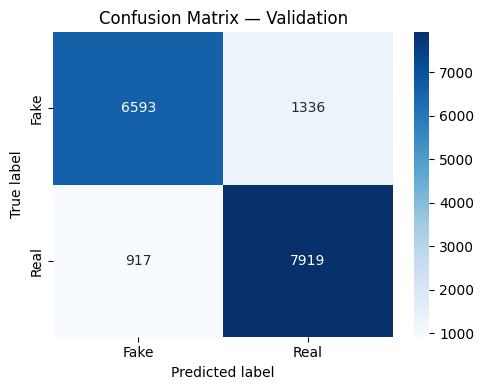

In [37]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate(model, X, y_true, split_name=""):
    y_pred  = model.predict(X)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X)[:, 1]
    else:
        y_proba = model.decision_function(X)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)

    print(f"\n{'='*40}")
    print(f"  {split_name} Results")
    print(f"{'='*40}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Fake','Real'])}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
    plt.title(f'Confusion Matrix — {split_name}')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

    return acc, auc

val_acc, val_auc = evaluate(xgb, X_val_full,  y_val,  "Validation")


  Test Results
  Accuracy : 0.8691
  ROC-AUC  : 0.9425

              precision    recall  f1-score   support

        Fake       0.88      0.84      0.86      7930
        Real       0.86      0.90      0.88      8835

    accuracy                           0.87     16765
   macro avg       0.87      0.87      0.87     16765
weighted avg       0.87      0.87      0.87     16765



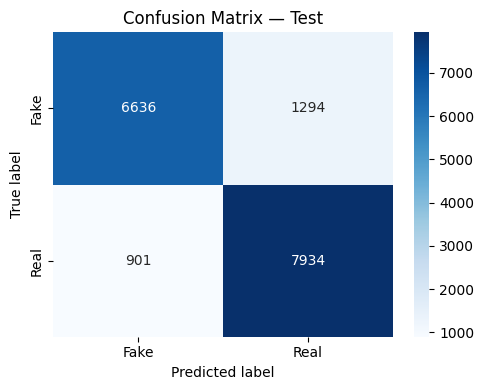

In [38]:
test_acc, test_auc = evaluate(xgb, X_test_full, y_test, "Test")



  LR Validation Results
  Accuracy : 0.8839
  ROC-AUC  : 0.9530

              precision    recall  f1-score   support

        Fake       0.87      0.88      0.88      7929
        Real       0.89      0.89      0.89      8836

    accuracy                           0.88     16765
   macro avg       0.88      0.88      0.88     16765
weighted avg       0.88      0.88      0.88     16765



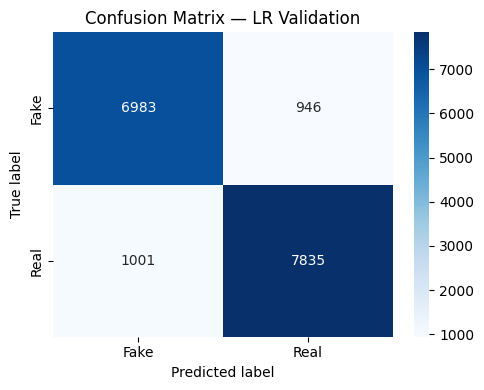


  LR Test Results
  Accuracy : 0.8888
  ROC-AUC  : 0.9545

              precision    recall  f1-score   support

        Fake       0.88      0.88      0.88      7930
        Real       0.90      0.89      0.89      8835

    accuracy                           0.89     16765
   macro avg       0.89      0.89      0.89     16765
weighted avg       0.89      0.89      0.89     16765



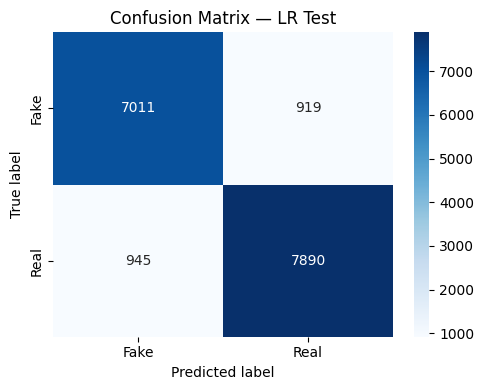


=== Model Comparison ===
XGBoost  — Val Acc: 0.8656 | Val AUC: 0.9400
Log. Reg — Val Acc: 0.8839 | Val AUC: 0.9530


In [39]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)
lr.fit(X_train_full, y_train)

lr_val_acc, lr_val_auc = evaluate(lr, X_val_full, y_val, 'LR Validation')
lr_test_acc, lr_test_auc = evaluate(lr, X_test_full, y_test, 'LR Test')

print('\n=== Model Comparison ===')
print(f'XGBoost  — Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}')
print(f'Log. Reg — Val Acc: {lr_val_acc:.4f} | Val AUC: {lr_val_auc:.4f}')


In [40]:
from sklearn.preprocessing import MinMaxScaler
import scipy.sparse as sp

# Re-scale StandardScaled (because it can be negative)
# with MinMaxScaler before combining with TF-IDF.

meta_scaler_nb = MinMaxScaler()
X_meta_train_mm = meta_scaler_nb.fit_transform(X_meta_train)
X_meta_val_mm   = meta_scaler_nb.transform(X_meta_val)
X_meta_test_mm  = meta_scaler_nb.transform(X_meta_test)

X_train_nb = sp.hstack([X_tfidf_train, sp.csr_matrix(X_meta_train_mm)])
X_val_nb   = sp.hstack([X_tfidf_val,   sp.csr_matrix(X_meta_val_mm)])
X_test_nb  = sp.hstack([X_tfidf_test,  sp.csr_matrix(X_meta_test_mm)])


  ComplementNB Validation Results
  Accuracy : 0.8509
  ROC-AUC  : 0.9269

              precision    recall  f1-score   support

        Fake       0.85      0.83      0.84      7929
        Real       0.85      0.87      0.86      8836

    accuracy                           0.85     16765
   macro avg       0.85      0.85      0.85     16765
weighted avg       0.85      0.85      0.85     16765



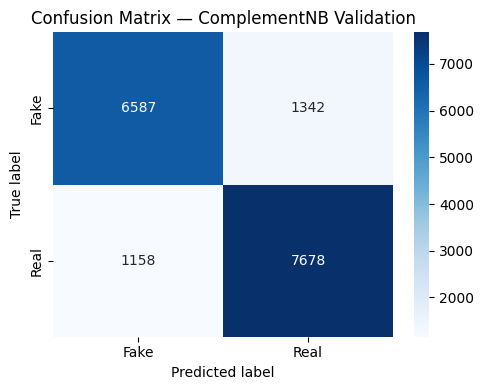


  ComplementNB Test Results
  Accuracy : 0.8564
  ROC-AUC  : 0.9294

              precision    recall  f1-score   support

        Fake       0.86      0.83      0.85      7930
        Real       0.85      0.88      0.87      8835

    accuracy                           0.86     16765
   macro avg       0.86      0.86      0.86     16765
weighted avg       0.86      0.86      0.86     16765



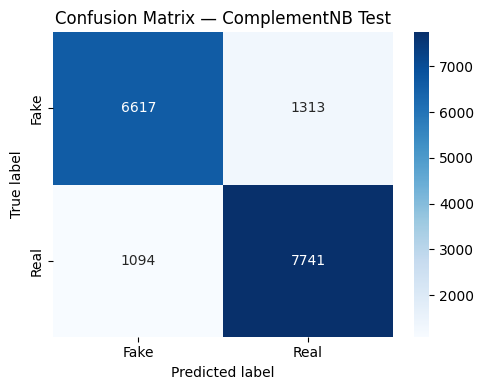

In [41]:
from sklearn.naive_bayes import ComplementNB

cnb = ComplementNB(alpha=0.1)
cnb.fit(X_train_nb, y_train)

cnb_val_acc,  cnb_val_auc  = evaluate(cnb, X_val_nb,  y_val,  "ComplementNB Validation")
cnb_test_acc, cnb_test_auc = evaluate(cnb, X_test_nb, y_test, "ComplementNB Test")

              Model  Val Acc  Val AUC  Test Acc  Test AUC
Logistic Regression 0.883865 0.952968  0.888816  0.954506
            XGBoost 0.865613 0.940028  0.869072  0.942500
       ComplementNB 0.850880 0.926946  0.856427  0.929428


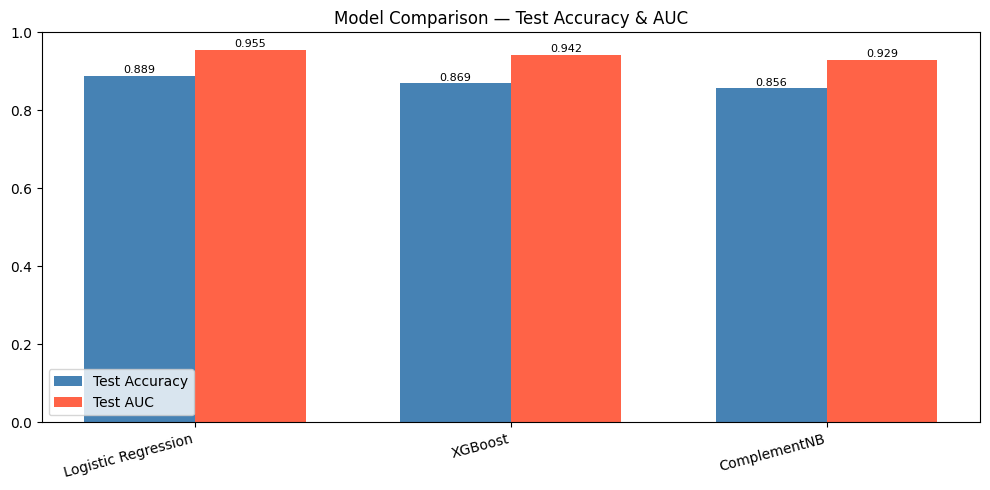

In [42]:
# Summary comparison of all models
import pandas as pd
import matplotlib.pyplot as plt

summary = pd.DataFrame({
    'Model':    ['Logistic Regression', 'XGBoost', 'ComplementNB'],
    'Val Acc':  [lr_val_acc,  val_acc,  cnb_val_acc],
    'Val AUC':  [lr_val_auc,  val_auc,  cnb_val_auc],
    'Test Acc': [lr_test_acc, test_acc, cnb_test_acc],
    'Test AUC': [lr_test_auc, test_auc, cnb_test_auc],
})
summary = summary.sort_values('Test AUC', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

# Bar chart — Test Accuracy vs Test AUC
x = range(len(summary))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - width/2 for i in x], summary['Test Acc'], width, label='Test Accuracy', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], summary['Test AUC'], width, label='Test AUC',      color='tomato')
ax.set_xticks(list(x))
ax.set_xticklabels(summary['Model'], rotation=15, ha='right')
ax.set_ylim(0.0, 1.0)
ax.set_title('Model Comparison — Test Accuracy & AUC')
ax.legend()
for bar in bars1: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                          f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                          f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


In [43]:
# Auto-select best model by Test AUC and save
import pickle

candidates = [
    {
        'name':       'Logistic Regression',
        'model':      lr,
        'scaler':     scaler,          # StandardScaler
        'test_auc':   lr_test_auc,
        'test_acc':   lr_test_acc,
        'uses_nb':    False,
    },
    {
        'name':       'XGBoost',
        'model':      xgb,
        'scaler':     scaler,          # StandardScaler
        'test_auc':   test_auc,
        'test_acc':   test_acc,
        'uses_nb':    False,
    },
    {
        'name':       'ComplementNB',
        'model':      cnb,
        'scaler':     meta_scaler_nb,  # MinMaxScaler
        'test_auc':   cnb_test_auc,
        'test_acc':   cnb_test_acc,
        'uses_nb':    True,
    },
]

best = max(candidates, key=lambda c: c['test_auc'])

print("=== Model Selection ===")
for c in sorted(candidates, key=lambda c: c['test_auc'], reverse=True):
    marker = '   BEST' if c['name'] == best['name'] else ''
    print(f"  {c['name']:<25}  AUC: {c['test_auc']:.4f}  Acc: {c['test_acc']:.4f}{marker}")

print(f"\nSaving: {best['name']}")

best_model      = best['model']
best_scaler     = best['scaler']
best_uses_nb    = best['uses_nb']   # tells predict_headline which scaler path to use
best_model_name = best['name']

with open('model.pkl',  'wb') as f: pickle.dump(best_model,  f)
with open('tfidf.pkl',  'wb') as f: pickle.dump(tfidf,       f)
with open('scaler.pkl', 'wb') as f: pickle.dump(best_scaler, f)

print('Saved: model.pkl, tfidf.pkl, scaler.pkl')

=== Model Selection ===
  Logistic Regression        AUC: 0.9545  Acc: 0.8888   BEST
  XGBoost                    AUC: 0.9425  Acc: 0.8691
  ComplementNB               AUC: 0.9294  Acc: 0.8564

Saving: Logistic Regression
Saved: model.pkl, tfidf.pkl, scaler.pkl


In [44]:
# Test
import scipy.sparse as sp

def predict_headline(headline, model=best_model):
    clean   = preprocess(headline)
    tfidf_v = tfidf.transform([clean])
    meta    = pd.DataFrame([extract_meta_features(headline)])
    meta_sc = sp.csr_matrix(best_scaler.transform(meta))
    X       = sp.hstack([tfidf_v, meta_sc])

    pred  = model.predict(X)[0]
    prob  = model.predict_proba(X)[0]
    label = 'REAL' if pred == 1 else 'FAKE'

    print(f'Model    : {best_model_name}')
    print(f'Headline : {headline}')
    print(f'Result   : {label}  (confidence: {prob[pred]*100:.1f}%)')
    print(f'Fake: {prob[0]*100:.1f}%  |  Real: {prob[1]*100:.1f}%')
    print('-' * 60)

predict_headline('Scientists confirm major climate breakthrough at summit')
predict_headline('SHOCKING: Secret government plot EXPOSED you wont believe this!')
predict_headline('Federal Reserve raises interest rates by 0.25 percentage points')
predict_headline('You wont believe what this celebrity did — the truth exposed!')

Model    : Logistic Regression
Headline : Scientists confirm major climate breakthrough at summit
Result   : FAKE  (confidence: 86.0%)
Fake: 86.0%  |  Real: 14.0%
------------------------------------------------------------
Model    : Logistic Regression
Headline : SHOCKING: Secret government plot EXPOSED you wont believe this!
Result   : REAL  (confidence: 94.9%)
Fake: 5.1%  |  Real: 94.9%
------------------------------------------------------------
Model    : Logistic Regression
Headline : Federal Reserve raises interest rates by 0.25 percentage points
Result   : FAKE  (confidence: 71.2%)
Fake: 71.2%  |  Real: 28.8%
------------------------------------------------------------
Model    : Logistic Regression
Headline : You wont believe what this celebrity did — the truth exposed!
Result   : REAL  (confidence: 50.2%)
Fake: 49.8%  |  Real: 50.2%
------------------------------------------------------------
